In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!rm -rf /content/FineTuning /content/ocr_benchmark_utils.py
!unzip -q /content/drive/MyDrive/Magisterka/polish_forms_trocr_colab.zip -d /content
%cd /content
!pip -q install "transformers>=5.0.0" accelerate datasets jiwer openpyxl "pandas==2.2.2" "pillow<12"

/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 125.2 MB/s eta 0:00:00


In [3]:
from pathlib import Path

p = Path('/content/FineTuning/TrOCR/train_trocr.py')
s = p.read_text(encoding='utf-8')
s = s.replace('        tokenizer=processor.tokenizer,\n', '')
p.write_text(s, encoding='utf-8')

print('Patched:', p)

Patched: /content/FineTuning/TrOCR/train_trocr.py


In [4]:
from pathlib import Path

p = Path('/content/FineTuning/TrOCR/train_trocr.py')
s = p.read_text(encoding='utf-8')

old = """    model.config.max_length = args.max_target_length
    model.config.early_stopping = True
    model.config.no_repeat_ngram_size = 3
    model.config.length_penalty = 2.0
    model.config.num_beams = 4
"""

new = """    model.generation_config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.generation_config.pad_token_id = processor.tokenizer.pad_token_id
    model.generation_config.eos_token_id = processor.tokenizer.sep_token_id
    model.generation_config.max_length = args.max_target_length
    model.generation_config.early_stopping = True
    model.generation_config.no_repeat_ngram_size = 3
    model.generation_config.length_penalty = 2.0
    model.generation_config.num_beams = 4
"""

s = s.replace(old, new)
s = s.replace('        tokenizer=processor.tokenizer,\n', '')
p.write_text(s, encoding='utf-8')

print('Patched:', p)

Patched: /content/FineTuning/TrOCR/train_trocr.py


In [11]:
!rm -rf /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard

In [12]:
!python /content/FineTuning/TrOCR/train_trocr.py \
  --model-id microsoft/trocr-large-handwritten \
  --train-csv /content/FineTuning/data/trocr/train.csv \
  --val-csv /content/FineTuning/data/trocr/val.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard \
  --epochs 10 \
  --batch-size 2 \
  --grad-accum 8 \
  --learning-rate 5e-5 \
  --gradient-checkpointing

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100% 635/635 [00:00<00:00, 753.97it/s, Materializing param=encoder.layernorm.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-large-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly ini

In [13]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard \
  --test-csv /content/FineTuning/data/trocr/test.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard \
  --run-name trocr_large_standard

Loading weights: 100% 637/637 [00:00<00:00, 752.99it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 50/241
processed 100/241
processed 150/241
processed 200/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard/trocr_large_standard_summary.csv


In [14]:
import pandas as pd

pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard/trocr_large_standard_summary.csv')

,model_id,dataset,source_dataset,preprocessing_variant,samples,cer_mean,cer_median,corpus_cer,wer_mean,wer_median,...,word_substitutions,word_insertions,word_deletions,correct_recognized_words,inference_seconds_total,inference_seconds_mean,inference_seconds_median,rss_after_mb_max,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,trocr_large_standard,polish_forms_test,polish_forms,native,241,0.01507,0.0,0.015564,0.051253,0.0,...,82,4,6,1635,69.556076,0.288614,0.280397,NaN,1220.814941,1456.0


In [15]:
g = pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard/trocr_large_standard_group_summary.csv')
g[['group', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,dysgrafia,46,0.028865,0.093939,0.981409,0.906061
1,inne,36,0.032588,0.089796,0.969968,0.926531
2,nie,159,0.008004,0.033972,0.994523,0.966028


In [16]:
!python /content/FineTuning/TrOCR/train_trocr.py \
  --model-id microsoft/trocr-large-handwritten \
  --train-csv /content/FineTuning/data/trocr/train_dysgraphia_oversampled.csv \
  --val-csv /content/FineTuning/data/trocr/val.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled \
  --epochs 10 \
  --batch-size 2 \
  --grad-accum 8 \
  --learning-rate 5e-5 \
  --gradient-checkpointing

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100% 635/635 [00:00<00:00, 721.02it/s, Materializing param=encoder.layernorm.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-large-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly ini

In [17]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled \
  --test-csv /content/FineTuning/data/trocr/test.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled \
  --run-name trocr_large_dysgraphia_oversampled

Loading weights: 100% 637/637 [00:00<00:00, 743.72it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 50/241
processed 100/241
processed 150/241
processed 200/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled/trocr_large_dysgraphia_oversampled_summary.csv


In [18]:
import pandas as pd
from pathlib import Path

DRIVE = Path('/content/drive/MyDrive/Magisterka')

runs = [
    'trocr_large_standard',
    'trocr_large_dysgraphia_oversampled',
]

rows = []
groups = []

for run in runs:
    root = DRIVE / 'evaluation' / run
    rows.append(pd.read_csv(root / f'{run}_summary.csv'))
    g = pd.read_csv(root / f'{run}_group_summary.csv')
    g['run'] = run
    groups.append(g)

summary = pd.concat(rows, ignore_index=True)
group_summary = pd.concat(groups, ignore_index=True)

display(summary[[
    'model_id', 'dataset', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max', 'cuda_peak_reserved_mb_max'
]])

display(group_summary[[
    'run', 'group', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw'
]])

,model_id,dataset,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,trocr_large_standard,polish_forms_test,241,0.015564,0.053395,0.988444,0.948926,0.288614,1220.814941,1456.0
1,trocr_large_dysgraphia_oversampled,polish_forms_test,241,0.015005,0.053395,0.990028,0.948926,0.271124,1222.135254,1456.0


,run,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,trocr_large_standard,dysgrafia,46,0.028865,0.093939,0.981409,0.906061
1,trocr_large_standard,inne,36,0.032588,0.089796,0.969968,0.926531
2,trocr_large_standard,nie,159,0.008004,0.033972,0.994523,0.966028
3,trocr_large_dysgraphia_oversampled,dysgrafia,46,0.021526,0.081818,0.986791,0.918182
4,trocr_large_dysgraphia_oversampled,inne,36,0.021086,0.077551,0.982109,0.934694
5,trocr_large_dysgraphia_oversampled,nie,159,0.011796,0.040070,0.992698,0.960801


trocr_large_standard ['/content/drive/MyDrive/Magisterka/outputs/trocr_large_standard/checkpoint-1000/trainer_state.json', '/content/drive/MyDrive/Magisterka/outputs/trocr_large_standard/checkpoint-1100/trainer_state.json', '/content/drive/MyDrive/Magisterka/outputs/trocr_large_standard/checkpoint-1160/trainer_state.json']


,step,loss,eval_loss,learning_rate,epoch
175,840,0.086242,NaN,1.456443e-05,7.242950
176,860,0.136316,NaN,1.365699e-05,7.416486
177,880,0.079683,NaN,1.274955e-05,7.590022
178,900,0.096516,NaN,1.184211e-05,7.763557
179,900,NaN,0.084677,NaN,7.763557
180,920,0.091594,NaN,1.093466e-05,7.937093
181,940,0.058645,NaN,1.002722e-05,8.104121
182,960,0.046831,NaN,9.119782e-06,8.277657
183,980,0.036768,NaN,8.212341e-06,8.451193
184,1000,0.032127,NaN,7.304900e-06,8.624729


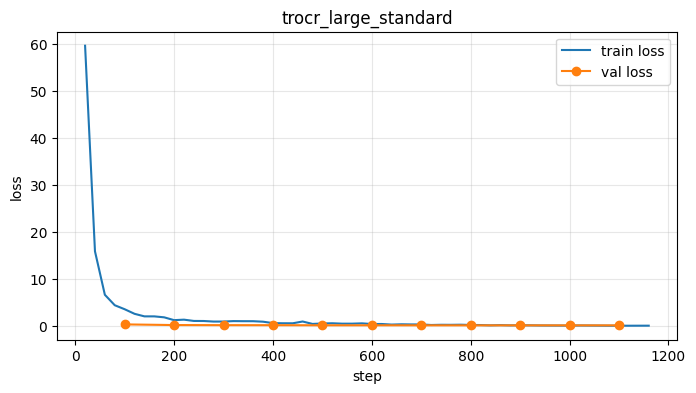

trocr_large_dysgraphia_oversampled ['/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1300/trainer_state.json', '/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1400/trainer_state.json', '/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1500/trainer_state.json', '/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600/trainer_state.json']


,step,loss,eval_loss,learning_rate,epoch
328,1300,0.035273,NaN,0.000012,7.785607
329,1300,NaN,0.088130,NaN,7.785607
330,1320,0.048147,NaN,0.000011,7.905547
331,1340,0.032358,NaN,0.000010,8.023988
332,1360,0.037880,NaN,0.000010,8.143928
333,1380,0.037400,NaN,0.000009,8.263868
334,1400,0.033385,NaN,0.000009,8.383808
335,1400,NaN,0.090878,NaN,8.383808
336,1420,0.015945,NaN,0.000008,8.503748
337,1440,0.026618,NaN,0.000007,8.623688


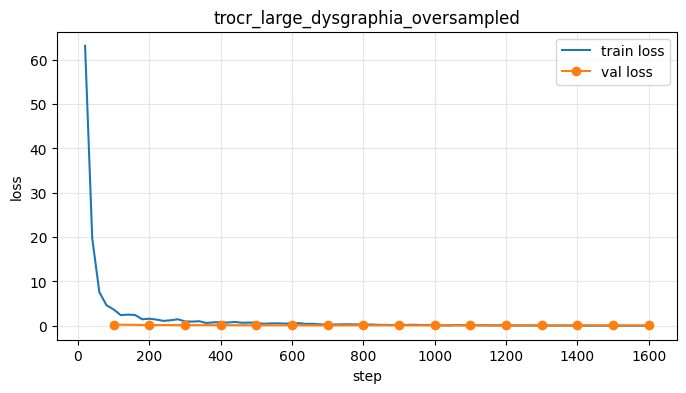

In [5]:
import json, glob
import pandas as pd
import matplotlib.pyplot as plt

for run in ['trocr_large_standard', 'trocr_large_dysgraphia_oversampled']:
    state_files = glob.glob(f'/content/drive/MyDrive/Magisterka/outputs/{run}/**/trainer_state.json', recursive=True)
    print(run, state_files)

    rows = []
    for path in state_files:
        with open(path, encoding='utf-8') as f:
            state = json.load(f)
        for r in state.get('log_history', []):
            r = dict(r)
            r['state_file'] = path
            rows.append(r)

    logs = pd.DataFrame(rows)
    display(logs[['step', 'loss', 'eval_loss', 'learning_rate', 'epoch']].dropna(how='all').tail(20))

    train = logs[logs.get('loss').notna()].drop_duplicates('step').sort_values('step')
    val = logs[logs.get('eval_loss').notna()].drop_duplicates('step').sort_values('step')

    plt.figure(figsize=(8,4))
    if not train.empty:
        plt.plot(train['step'], train['loss'], label='train loss')
    if not val.empty:
        plt.plot(val['step'], val['eval_loss'], marker='o', label='val loss')
    plt.title(run)
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [6]:
from pathlib import Path

p = Path('/content/FineTuning/TrOCR/evaluate_trocr.py')
s = p.read_text(encoding='utf-8')

old = '''                    "dataset": "polish_forms_test",
                    "source_dataset": "polish_forms",
                    "preprocessing_variant": "native",
                    "group": row["difficulty_group"],
'''

new = '''                    "dataset": row.get("dataset", "polish_forms_test"),
                    "source_dataset": row.get("source_dataset", "polish_forms"),
                    "preprocessing_variant": row.get("preprocessing_variant", "native"),
                    "group": row.get("difficulty_group", row.get("group", "")),
'''

s = s.replace(old, new)
p.write_text(s, encoding='utf-8')
print('Patched:', p)

Patched: /content/FineTuning/TrOCR/evaluate_trocr.py


In [7]:
!unzip -oq /content/drive/MyDrive/Magisterka/malaysian_qwen_external_validation_colab.zip -d /content

In [8]:
import json
import pandas as pd
from pathlib import Path

root = Path('/content/FineTuning/malaysian_external_qwen')
out = Path('/content/FineTuning/malaysian_external_trocr/trocr')
out.mkdir(parents=True, exist_ok=True)

def qwen_json_to_trocr_csv(json_name, csv_name):
    data = json.loads((root / 'qwen' / json_name).read_text(encoding='utf-8'))
    rows = []
    for item in data:
        m = item.get('metadata', {})
        rows.append({
            'sample_id': item['id'],
            'image_relpath': item['image'],
            'text': item['conversations'][1]['value'],
            'difficulty_group': m.get('difficulty_group', m.get('group', '')),
            'dataset': m.get('dataset', csv_name.replace('.csv', '')),
            'source_dataset': m.get('source_dataset', 'malaysian'),
            'preprocessing_variant': m.get('preprocessing_variant', 'raw'),
        })
    pd.DataFrame(rows).to_csv(out / csv_name, index=False)

qwen_json_to_trocr_csv('malaysian_raw.json', 'malaysian_raw.csv')
qwen_json_to_trocr_csv('malaysian_auto_invert.json', 'malaysian_auto_invert.csv')

print(pd.read_csv(out / 'malaysian_raw.csv').head())

           sample_id                     image_relpath  \
0  LPD_001_t1_l1_raw  images/raw/LPD_001_t1_l1_raw.png   
1  LPD_002_t2_l1_raw  images/raw/LPD_002_t2_l1_raw.png   
2  LPD_002_t2_l2_raw  images/raw/LPD_002_t2_l2_raw.png   
3  LPD_003_t3_l1_raw  images/raw/LPD_003_t3_l1_raw.png   
4  LPD_003_t3_l2_raw  images/raw/LPD_003_t3_l2_raw.png   

                                                text difficulty_group  \
0                    Baju itu baru dibeli oleh emak.              LPD   
1        Burung itu berada di dalam sangkar. Sangkar              LPD   
2                               baru itu milik bapa.              LPD   
3  Saya suka bermain basikal pada waktu lapang. B...              LPD   
4  dibeli oleh ayah saya. Roda basikal saya berwarna              LPD   

         dataset source_dataset preprocessing_variant  
0  malaysian_raw      malaysian                   raw  
1  malaysian_raw      malaysian                   raw  
2  malaysian_raw      malaysian             

In [11]:
from pathlib import Path
from transformers import TrOCRProcessor

out = Path('/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled')

print("Folder exists:", out.exists())
print("Files before:")
for p in sorted(out.glob("*")):
    print(p.name)

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")
processor.save_pretrained(out)

print("\nFiles after:")
for p in sorted(out.glob("*")):
    print(p.name)

Folder exists: True
Files before:
checkpoint-1300
checkpoint-1400
checkpoint-1500
checkpoint-1600


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]


Files after:
checkpoint-1300
checkpoint-1400
checkpoint-1500
checkpoint-1600
processor_config.json
tokenizer.json
tokenizer_config.json


In [14]:
!find /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled -maxdepth 2 -type f | sed 's#/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/##' | head -120

checkpoint-1300/config.json
checkpoint-1300/generation_config.json
checkpoint-1300/model.safetensors
checkpoint-1300/training_args.bin
checkpoint-1300/optimizer.pt
checkpoint-1300/scheduler.pt
checkpoint-1300/scaler.pt
checkpoint-1300/rng_state.pth
checkpoint-1300/trainer_state.json
checkpoint-1400/config.json
checkpoint-1400/generation_config.json
checkpoint-1400/model.safetensors
checkpoint-1400/training_args.bin
checkpoint-1400/optimizer.pt
checkpoint-1400/scheduler.pt
checkpoint-1400/scaler.pt
checkpoint-1400/rng_state.pth
checkpoint-1400/trainer_state.json
checkpoint-1500/config.json
checkpoint-1500/generation_config.json
checkpoint-1500/model.safetensors
checkpoint-1500/training_args.bin
checkpoint-1500/optimizer.pt
checkpoint-1500/scheduler.pt
checkpoint-1500/scaler.pt
checkpoint-1500/rng_state.pth
checkpoint-1500/trainer_state.json
checkpoint-1600/config.json
checkpoint-1600/generation_config.json
checkpoint-1600/model.safetensors
checkpoint-1600/training_args.bin
checkpoint-16

In [15]:
!ls -lah /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled

total 3.5M
drwx------ 2 root root 4.0K May 25 22:27 checkpoint-1300
drwx------ 2 root root 4.0K May 25 22:32 checkpoint-1400
drwx------ 2 root root 4.0K May 25 22:37 checkpoint-1500
drwx------ 2 root root 4.0K May 25 22:41 checkpoint-1600
-rw------- 1 root root  472 May 26 20:16 processor_config.json
-rw------- 1 root root  398 May 26 20:16 tokenizer_config.json
-rw------- 1 root root 3.4M May 26 20:16 tokenizer.json


In [16]:
from pathlib import Path
from transformers import TrOCRProcessor

ckpt = Path('/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600')

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")
processor.save_pretrained(ckpt)

print("Checkpoint files:")
for p in sorted(ckpt.glob("*")):
    print(p.name)

Checkpoint files:
config.json
generation_config.json
model.safetensors
processor_config.json
rng_state.pth
scaler.pt
scheduler.pt
tokenizer.json
tokenizer_config.json
trainer_state.json
training_args.bin


In [17]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600 \
  --test-csv /content/FineTuning/malaysian_external_trocr/trocr/malaysian_raw.csv \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled_malaysian_raw \
  --run-name trocr_large_dysgraphia_oversampled_malaysian_raw \
  --batch-size 2

Loading weights: 100% 637/637 [00:39<00:00, 16.09it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 50/424
processed 100/424
processed 150/424
processed 200/424
processed 250/424
processed 300/424
processed 350/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled_malaysian_raw/trocr_large_dysgraphia_oversampled_malaysian_raw_summary.csv


In [18]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600 \
  --test-csv /content/FineTuning/malaysian_external_trocr/trocr/malaysian_auto_invert.csv \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled_malaysian_auto_invert \
  --run-name trocr_large_dysgraphia_oversampled_malaysian_auto_invert \
  --batch-size 2

Loading weights: 100% 637/637 [00:00<00:00, 707.57it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 50/424
processed 100/424
processed 150/424
processed 200/424
processed 250/424
processed 300/424
processed 350/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled_malaysian_auto_invert/trocr_large_dysgraphia_oversampled_malaysian_auto_invert_summary.csv


In [1]:
import pandas as pd
from pathlib import Path

eval_root = Path('/content/drive/MyDrive/Magisterka/evaluation')

paths = [
    p for p in eval_root.glob('trocr_large*malaysian*/*_summary.csv')
    if not p.name.endswith('_group_summary.csv')
]

summary = pd.concat(
    [pd.read_csv(p).assign(run_dir=p.parent.name) for p in paths],
    ignore_index=True
)

summary[[
    'run_dir', 'dataset', 'preprocessing_variant', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max', 'cuda_peak_reserved_mb_max'
]].sort_values(['preprocessing_variant', 'corpus_cer'])

,run_dir,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
1,trocr_large_standard_malaysian_auto_invert,malaysian_auto_invert,auto_invert,424,0.908710,1.156546,0.205197,0.001972,0.144708,1268.846191,2256.0
3,trocr_large_dysgraphia_oversampled_malaysian_a...,malaysian_auto_invert,auto_invert,424,0.933663,1.149054,0.161339,0.000789,0.268950,1223.116211,1526.0
0,trocr_large_standard_malaysian_raw,malaysian_raw,raw,424,0.985702,1.165221,0.105932,0.000000,0.148501,1268.800293,2192.0
2,trocr_large_dysgraphia_oversampled_malaysian_raw,malaysian_raw,raw,424,0.986045,1.159306,0.094109,0.000394,0.266512,1222.308594,1490.0


In [2]:
group_paths = list(eval_root.glob('trocr_large*malaysian*/*_group_summary.csv'))

groups = pd.concat(
    [pd.read_csv(p).assign(run_dir=p.parent.name) for p in group_paths],
    ignore_index=True
)

groups[[
    'run_dir', 'group', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw'
]].sort_values(['run_dir', 'group'])

,run_dir,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
6,trocr_large_dysgraphia_oversampled_malaysian_a...,LPD,248,0.896093,1.111043,0.217001,0.000613
7,trocr_large_dysgraphia_oversampled_malaysian_a...,PD,176,1.003742,1.217439,0.057514,0.001104
4,trocr_large_dysgraphia_oversampled_malaysian_raw,LPD,248,0.941288,1.118405,0.158395,0.000000
5,trocr_large_dysgraphia_oversampled_malaysian_raw,PD,176,1.069529,1.232892,-0.025803,0.001104
2,trocr_large_standard_malaysian_auto_invert,LPD,248,0.860190,1.120245,0.278986,0.001840
3,trocr_large_standard_malaysian_auto_invert,PD,176,0.999212,1.221854,0.067560,0.002208
0,trocr_large_standard_malaysian_raw,LPD,248,0.925871,1.115951,0.189124,0.000000
1,trocr_large_standard_malaysian_raw,PD,176,1.097302,1.253863,-0.049242,0.000000


In [3]:
from datasets import load_dataset
import pandas as pd
from pathlib import Path

out_root = Path('/content/FineTuning/trocr_iam_eval')
img_dir = out_root / 'images'
img_dir.mkdir(parents=True, exist_ok=True)

ds = load_dataset('Teklia/IAM-line', split='test[:200]')

rows = []
for i, item in enumerate(ds):
    sample_id = f'iam_test_{i:05d}'
    img_name = f'{sample_id}.png'
    item['image'].convert('RGB').save(img_dir / img_name)
    rows.append({
        'sample_id': sample_id,
        'image_relpath': f'images/{img_name}',
        'text': item['text'],
        'difficulty_group': 'IAM-test',
        'dataset': 'iam_test_200',
        'source_dataset': 'iam',
        'preprocessing_variant': 'native',
    })

csv_path = out_root / 'iam_test_200.csv'
pd.DataFrame(rows).to_csv(csv_path, index=False)
csv_path

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.14k [00:00<?, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

PosixPath('/content/FineTuning/trocr_iam_eval/iam_test_200.csv')

In [4]:
from pathlib import Path
import subprocess, sys

DRIVE = Path('/content/drive/MyDrive/Magisterka')
EVAL = Path('/content/FineTuning/TrOCR/evaluate_trocr.py')

models = {
    'trocr_large_base_iam_200': 'microsoft/trocr-large-handwritten',
    'trocr_large_standard_iam_200': DRIVE / 'outputs/trocr_large_standard',
    'trocr_large_dysgraphia_oversampled_iam_200': DRIVE / 'outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600',
}

for run_name, model_path in models.items():
    out_dir = DRIVE / 'evaluation' / run_name
    summary_path = out_dir / f'{run_name}_summary.csv'

    if summary_path.exists():
        print('Już istnieje, pomijam:', run_name)
        continue

    cmd = [
        sys.executable, str(EVAL),
        '--model-path', str(model_path),
        '--test-csv', str(csv_path),
        '--data-root', str(out_root),
        '--output-dir', str(out_dir),
        '--run-name', run_name,
        '--batch-size', '4',
    ]

    print('Uruchamiam:', run_name)
    subprocess.run(cmd, check=True)

Uruchamiam: trocr_large_base_iam_200
Uruchamiam: trocr_large_standard_iam_200
Uruchamiam: trocr_large_dysgraphia_oversampled_iam_200


In [5]:
paths = [
    p for p in eval_root.glob('trocr_large*/*_summary.csv')
    if not p.name.endswith('_group_summary.csv')
]

all_trocr = pd.concat(
    [pd.read_csv(p).assign(run_dir=p.parent.name) for p in paths],
    ignore_index=True
)

all_trocr[[
    'run_dir', 'dataset', 'preprocessing_variant', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max', 'cuda_peak_reserved_mb_max'
]].sort_values(['dataset', 'corpus_cer'])

,run_dir,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
5,trocr_large_base_iam_200,iam_test_200,native,200,0.040395,0.104575,0.969159,0.897939,0.073247,1259.263184,1618.0
6,trocr_large_standard_iam_200,iam_test_200,native,200,0.779751,0.968326,0.378193,0.062343,0.143022,1268.830078,2256.0
7,trocr_large_dysgraphia_oversampled_iam_200,iam_test_200,native,200,0.796158,0.984917,0.365005,0.032680,0.148908,1269.606445,2322.0
2,trocr_large_standard_malaysian_auto_invert,malaysian_auto_invert,auto_invert,424,0.908710,1.156546,0.205197,0.001972,0.144708,1268.846191,2256.0
4,trocr_large_dysgraphia_oversampled_malaysian_a...,malaysian_auto_invert,auto_invert,424,0.933663,1.149054,0.161339,0.000789,0.268950,1223.116211,1526.0
1,trocr_large_standard_malaysian_raw,malaysian_raw,raw,424,0.985702,1.165221,0.105932,0.000000,0.148501,1268.800293,2192.0
3,trocr_large_dysgraphia_oversampled_malaysian_raw,malaysian_raw,raw,424,0.986045,1.159306,0.094109,0.000394,0.266512,1222.308594,1490.0
0,trocr_large_standard,polish_forms_test,native,241,0.015564,0.053395,0.988444,0.948926,0.288614,1220.814941,1456.0


In [6]:
import pandas as pd
from pathlib import Path

eval_root = Path('/content/drive/MyDrive/Magisterka/evaluation')

for run in [
    'trocr_large_standard_malaysian_auto_invert',
    'trocr_large_standard_iam_200',
    'trocr_large_base_iam_200',
]:
    pred_path = eval_root / run / f'{run}_predictions.csv'
    print('\n###', run)
    pred = pd.read_csv(pred_path)
    display(pred[['sample_id', 'group', 'reference', 'prediction', 'cer', 'wer']].head(10))


### trocr_large_standard_malaysian_auto_invert


,sample_id,group,reference,prediction,cer,wer
0,LPD_001_t1_l1_auto_invert,LPD,Baju itu baru dibeli oleh emak.,Bóg nitwo wazraża światła plecach miecz.,0.838710,1.00
1,LPD_002_t2_l1_auto_invert,LPD,Burung itu berada di dalam sangkar. Sangkar,"„Bchnążw będz, chan grym skrę.",0.790698,1.00
2,LPD_002_t2_l2_auto_invert,LPD,baru itu milik bapa.,bar w stan mieć krzyżkę.,0.700000,1.25
3,LPD_003_t3_l1_auto_invert,LPD,Saya suka bermain basikal pada waktu lapang. B...,Sęsta mgła powoli zasłoniła światła logarę.Btośkę,0.714286,1.00
4,LPD_003_t3_l2_auto_invert,LPD,dibeli oleh ayah saya. Roda basikal saya berwarna,Żółw odległo siędzta światła starego miasta,0.775510,1.00
5,LPD_003_t3_l3_auto_invert,LPD,hijau dan putih.,„ a może niez na plecach miecz i sie.,1.937500,3.00
6,LPD_004_t1_l1_auto_invert,LPD,Baju itu baru dibeli oleh emak.,"Bywam, ażw odikuła światła starego miasta.",0.967742,1.00
7,LPD_005_t2_l1_auto_invert,LPD,Burung itu berada di dalam sangkar. Sangkar,"„Bchną łódź, chrości okośnie spotkanie zespoła.",0.860465,1.00
8,LPD_005_t2_l2_auto_invert,LPD,baru itu milik bapa.,Żółw powoli” buri” księżkę.,1.100000,1.00
9,LPD_006_t3_l1_auto_invert,LPD,Saya suka bermain basikal pada waktu lapang.,Saga znalezion ksiąświatł powiedziała laparę.,0.681818,1.00



### trocr_large_standard_iam_200


,sample_id,group,reference,prediction,cer,wer
0,iam_test_00000,IAM-test,"assuredness "" Bella Bella Marie "" ( Parlophone...","kędziesz ""Bódz kości”plik twój i sześ tocały m...",0.774194,1.000000
1,iam_test_00001,IAM-test,I don't think he will storm the charts with th...,Mieć Pół mili stom tha plecach miecz nała lub ...,0.696203,1.000000
2,iam_test_00002,IAM-test,"CHRIS CHARLES , 39 , who lives in Stockton-on-...","KARES, 38, userziesz in Strówam=23.35wam skrach.",0.690141,0.928571
3,iam_test_00003,IAM-test,Become a success with a disc and hey presto ! ...,"Bywam, a success wółości” krętąścieżke spotkan...",0.686747,0.894737
4,iam_test_00004,IAM-test,"Tolch , as he is known in Tin Pan Alley , like...",Tółw odległości�an lub oświatła starego miasta.,0.788889,1.000000
5,iam_test_00005,IAM-test,""" My September Love , "" the big David Whitfiel...",Spotkanie rozpocz” — stan gry właświatę wiatła...,0.868852,1.000000
6,iam_test_00006,IAM-test,He is also a director of a couple of garages ....,W odko a director of a może n plik rapła sieśn...,0.604651,0.761905
7,iam_test_00007,IAM-test,"writer . He writes with Tolchard Evans , compo...",Miecz. Na plecach. Dlacziesz krętanieżkę w sal...,0.780220,1.000000
8,iam_test_00008,IAM-test,"The numbers include "" Scotland the Brave , "" ""...","Miecz krędziesz plikaczke zespoł stan grytanie,",0.784615,1.000000
9,iam_test_00009,IAM-test,"Fay Compton stars in "" No Hiding Place "" (I T ...","Gracz zapisał stans 12 metrów odzkeś Litwo, 9....",0.698413,0.941176



### trocr_large_base_iam_200


,sample_id,group,reference,prediction,cer,wer
0,iam_test_00000,IAM-test,"assuredness "" Bella Bella Marie "" ( Parlophone...","assuredness "" Bella Bella Marie "" ( Parlophone...",0.010753,0.055556
1,iam_test_00001,IAM-test,I don't think he will storm the charts with th...,I don't think he will storm the charts with th...,0.012658,0.105263
2,iam_test_00002,IAM-test,"CHRIS CHARLES , 39 , who lives in Stockton-on-...","CHRIS CHARLES , 39 , who lives in Stockholm-on...",0.070423,0.214286
3,iam_test_00003,IAM-test,Become a success with a disc and hey presto ! ...,Become a success with a disc and key presto ! ...,0.048193,0.210526
4,iam_test_00004,IAM-test,"Tolch , as he is known in Tin Pan Alley , like...","Tolch , as he is known in Tin Pan Alley , live...",0.011111,0.045455
5,iam_test_00005,IAM-test,""" My September Love , "" the big David Whitfiel...",""" My September love , "" the big David Whitfiel...",0.016393,0.071429
6,iam_test_00006,IAM-test,He is also a director of a couple of garages ....,He is also a director of a couple of garages ....,0.000000,0.000000
7,iam_test_00007,IAM-test,"writer . He writes with Tolchard Evans , compo...","writer . He writes with Tolchard Evans , compo...",0.000000,0.000000
8,iam_test_00008,IAM-test,"The numbers include "" Scotland the Brave , "" ""...","The yumbers include "" Scotland the brave , "" ""...",0.030769,0.133333
9,iam_test_00009,IAM-test,"Fay Compton stars in "" No Hiding Place "" (I T ...","fay Compton stars in "" No hiding Place "" ( ITV...",0.079365,0.294118


In [7]:
from pathlib import Path
from transformers import TrOCRProcessor

ckpt = Path('/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600')
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")
processor.save_pretrained(ckpt)

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


['/content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600/processor_config.json']

In [8]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_dysgraphia_oversampled/checkpoint-1600 \
  --test-csv /content/FineTuning/data/trocr/test.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled \
  --run-name trocr_large_dysgraphia_oversampled \
  --batch-size 4

Loading weights: 100% 637/637 [00:00<00:00, 733.70it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 100/241
processed 200/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_dysgraphia_oversampled/trocr_large_dysgraphia_oversampled_summary.csv


In [9]:
paths = [
    p for p in eval_root.glob('trocr_large*/*_summary.csv')
    if not p.name.endswith('_group_summary.csv')
]

all_trocr = pd.concat(
    [pd.read_csv(p).assign(run_dir=p.parent.name) for p in paths],
    ignore_index=True
)

all_trocr[[
    'run_dir', 'dataset', 'preprocessing_variant', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max', 'cuda_peak_reserved_mb_max'
]].sort_values(['dataset', 'corpus_cer'])

,run_dir,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
5,trocr_large_base_iam_200,iam_test_200,native,200,0.040395,0.104575,0.969159,0.897939,0.073247,1259.263184,1618.0
6,trocr_large_standard_iam_200,iam_test_200,native,200,0.779751,0.968326,0.378193,0.062343,0.143022,1268.830078,2256.0
7,trocr_large_dysgraphia_oversampled_iam_200,iam_test_200,native,200,0.796158,0.984917,0.365005,0.032680,0.148908,1269.606445,2322.0
2,trocr_large_standard_malaysian_auto_invert,malaysian_auto_invert,auto_invert,424,0.908710,1.156546,0.205197,0.001972,0.144708,1268.846191,2256.0
4,trocr_large_dysgraphia_oversampled_malaysian_a...,malaysian_auto_invert,auto_invert,424,0.933663,1.149054,0.161339,0.000789,0.268950,1223.116211,1526.0
1,trocr_large_standard_malaysian_raw,malaysian_raw,raw,424,0.985702,1.165221,0.105932,0.000000,0.148501,1268.800293,2192.0
3,trocr_large_dysgraphia_oversampled_malaysian_raw,malaysian_raw,raw,424,0.986045,1.159306,0.094109,0.000394,0.266512,1222.308594,1490.0
8,trocr_large_dysgraphia_oversampled,polish_forms_test,native,241,0.014725,0.052815,0.990028,0.949507,0.149287,1268.846191,2256.0
0,trocr_large_standard,polish_forms_test,native,241,0.015564,0.053395,0.988444,0.948926,0.288614,1220.814941,1456.0


In [10]:
!python /content/FineTuning/TrOCR/train_trocr.py \
  --model-id microsoft/trocr-large-handwritten \
  --train-csv /content/FineTuning/data/trocr/train.csv \
  --val-csv /content/FineTuning/data/trocr/val.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard_soft_ft \
  --epochs 3 \
  --batch-size 2 \
  --grad-accum 8 \
  --learning-rate 1e-5 \
  --gradient-checkpointing

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100% 635/635 [00:00<00:00, 715.42it/s, Materializing param=encoder.layernorm.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-large-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly ini

In [11]:
from pathlib import Path
from transformers import TrOCRProcessor

soft = Path('/content/drive/MyDrive/Magisterka/outputs/trocr_large_standard_soft_ft')
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")
processor.save_pretrained(soft)

print("Files:")
for p in sorted(soft.glob("*")):
    print(p.name)

Files:
checkpoint-200
checkpoint-300
checkpoint-348
config.json
generation_config.json
model.safetensors
processor_config.json
tokenizer.json
tokenizer_config.json
training_args.bin


In [12]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard_soft_ft \
  --test-csv /content/FineTuning/data/trocr/test.csv \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft \
  --run-name trocr_large_standard_soft_ft \
  --batch-size 4

Loading weights: 100% 637/637 [00:00<00:00, 686.50it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 100/241
processed 200/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft/trocr_large_standard_soft_ft_summary.csv


In [13]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard_soft_ft \
  --test-csv /content/FineTuning/trocr_iam_eval/iam_test_200.csv \
  --data-root /content/FineTuning/trocr_iam_eval \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft_iam_200 \
  --run-name trocr_large_standard_soft_ft_iam_200 \
  --batch-size 4

Loading weights: 100% 637/637 [00:00<00:00, 753.36it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 100/200
processed 200/200
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft_iam_200/trocr_large_standard_soft_ft_iam_200_summary.csv


In [14]:
from datasets import load_dataset
import pandas as pd
from pathlib import Path

out_root = Path('/content/FineTuning/trocr_iam_eval')
img_dir = out_root / 'images'
img_dir.mkdir(parents=True, exist_ok=True)

ds = load_dataset('Teklia/IAM-line', split='test[:200]')

rows = []
for i, item in enumerate(ds):
    sample_id = f'iam_test_{i:05d}'
    img_name = f'{sample_id}.png'
    item['image'].convert('RGB').save(img_dir / img_name)
    rows.append({
        'sample_id': sample_id,
        'image_relpath': f'images/{img_name}',
        'text': item['text'],
        'difficulty_group': 'IAM-test',
        'dataset': 'iam_test_200',
        'source_dataset': 'iam',
        'preprocessing_variant': 'native',
    })

csv_path = out_root / 'iam_test_200.csv'
pd.DataFrame(rows).to_csv(csv_path, index=False)
csv_path

PosixPath('/content/FineTuning/trocr_iam_eval/iam_test_200.csv')

In [15]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard_soft_ft \
  --test-csv /content/FineTuning/malaysian_external_trocr/trocr/malaysian_raw.csv \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft_malaysian_raw \
  --run-name trocr_large_standard_soft_ft_malaysian_raw \
  --batch-size 4

Loading weights: 100% 637/637 [00:00<00:00, 742.45it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 100/424
processed 200/424
processed 300/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft_malaysian_raw/trocr_large_standard_soft_ft_malaysian_raw_summary.csv


In [16]:
!python /content/FineTuning/TrOCR/evaluate_trocr.py \
  --model-path /content/drive/MyDrive/Magisterka/outputs/trocr_large_standard_soft_ft \
  --test-csv /content/FineTuning/malaysian_external_trocr/trocr/malaysian_auto_invert.csv \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft_malaysian_auto_invert \
  --run-name trocr_large_standard_soft_ft_malaysian_auto_invert \
  --batch-size 4

Loading weights: 100% 637/637 [00:00<00:00, 699.41it/s, Materializing param=encoder.pooler.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
processed 100/424
processed 200/424
processed 300/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/trocr_large_standard_soft_ft_malaysian_auto_invert/trocr_large_standard_soft_ft_malaysian_auto_invert_summary.csv


In [17]:
import pandas as pd
from pathlib import Path

eval_root = Path('/content/drive/MyDrive/Magisterka/evaluation')

wanted = [
    'trocr_large_base_iam_200',
    'trocr_large_standard',
    'trocr_large_dysgraphia_oversampled',
    'trocr_large_standard_soft_ft',
    'trocr_large_standard_iam_200',
    'trocr_large_dysgraphia_oversampled_iam_200',
    'trocr_large_standard_soft_ft_iam_200',
    'trocr_large_standard_malaysian_raw',
    'trocr_large_standard_malaysian_auto_invert',
    'trocr_large_dysgraphia_oversampled_malaysian_raw',
    'trocr_large_dysgraphia_oversampled_malaysian_auto_invert',
    'trocr_large_standard_soft_ft_malaysian_raw',
    'trocr_large_standard_soft_ft_malaysian_auto_invert',
]

rows = []
for run in wanted:
    path = eval_root / run / f'{run}_summary.csv'
    if path.exists():
        rows.append(pd.read_csv(path).assign(run_dir=run))
    else:
        print("Brak:", run)

summary = pd.concat(rows, ignore_index=True)

summary[[
    'run_dir', 'dataset', 'preprocessing_variant', 'samples',
    'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max', 'cuda_peak_reserved_mb_max'
]].sort_values(['dataset', 'corpus_cer'])

,run_dir,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,trocr_large_base_iam_200,iam_test_200,native,200,0.040395,0.104575,0.969159,0.897939,0.073247,1259.263184,1618.0
6,trocr_large_standard_soft_ft_iam_200,iam_test_200,native,200,0.134579,0.330820,0.909761,0.672700,0.105147,1266.052734,2012.0
4,trocr_large_standard_iam_200,iam_test_200,native,200,0.779751,0.968326,0.378193,0.062343,0.143022,1268.830078,2256.0
5,trocr_large_dysgraphia_oversampled_iam_200,iam_test_200,native,200,0.796158,0.984917,0.365005,0.032680,0.148908,1269.606445,2322.0
12,trocr_large_standard_soft_ft_malaysian_auto_in...,malaysian_auto_invert,auto_invert,424,0.288307,0.724763,0.759263,0.293375,0.147532,1293.305664,3270.0
8,trocr_large_standard_malaysian_auto_invert,malaysian_auto_invert,auto_invert,424,0.908710,1.156546,0.205197,0.001972,0.144708,1268.846191,2256.0
10,trocr_large_dysgraphia_oversampled_malaysian_a...,malaysian_auto_invert,auto_invert,424,0.933663,1.149054,0.161339,0.000789,0.268950,1223.116211,1526.0
11,trocr_large_standard_soft_ft_malaysian_raw,malaysian_raw,raw,424,0.581701,0.963722,0.513233,0.058754,0.177053,1292.335449,3180.0
7,trocr_large_standard_malaysian_raw,malaysian_raw,raw,424,0.985702,1.165221,0.105932,0.000000,0.148501,1268.800293,2192.0
9,trocr_large_dysgraphia_oversampled_malaysian_raw,malaysian_raw,raw,424,0.986045,1.159306,0.094109,0.000394,0.266512,1222.308594,1490.0
